In [40]:
from pathlib import Path
import json
import shutil
from PIL import Image, ImageDraw, ImageFont
from tqdm.auto import tqdm

JSON_PATH = Path("/kaggle/input/datasets/phmthn/depth-information/bboxes_last.json")
DEPTH_IMAGE_DIR = Path("/kaggle/input/datasets/phmthn/depth-information/depth_output/output")

OUTPUT_DIR = Path("/kaggle/working/depth_bbox_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_JSON_PATH = Path("/kaggle/working/depth_bbox_selected.json")

print("JSON_PATH:", JSON_PATH)
print("DEPTH_IMAGE_DIR:", DEPTH_IMAGE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

JSON_PATH: /kaggle/input/datasets/phmthn/depth-information/bboxes_last.json
DEPTH_IMAGE_DIR: /kaggle/input/datasets/phmthn/depth-information/depth_output/output
OUTPUT_DIR: /kaggle/working/depth_bbox_output


In [39]:
# !rm -rf /kaggle/working/bbox_original_output

In [41]:
with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Total JSON items:", len(data))

depth_images = sorted(DEPTH_IMAGE_DIR.glob("*_depth.jpg"))
print("Total depth images:", len(depth_images))

print("Sample JSON item:")
print(json.dumps(data[0], indent=2, ensure_ascii=False)[:1500])

print("\nSample depth images:")
for p in depth_images[:10]:
    print(p.name)

Total JSON items: 1076
Total depth images: 1066
Sample JSON item:
{
  "id": 0,
  "image": "000000024001.jpg",
  "question": "If you were a person walking on the beach, on which side of you would the water be?",
  "O1": "the water",
  "O2": "a person walking on the beach",
  "image_width": 640,
  "image_height": 480,
  "detections": [
    {
      "label": "the water",
      "cls_id": 0,
      "confidence": null,
      "bbox_2d_1000": [
        0.0,
        408.0,
        1000.0,
        786.0
      ],
      "bbox_xyxy": [
        0.0,
        195.83999999999997,
        640.0,
        377.28000000000003
      ],
      "bbox_xywh": [
        0.0,
        195.83999999999997,
        640.0,
        181.44000000000005
      ],
      "bbox_source": "qwen"
    },
    {
      "label": "a person walking on the beach",
      "cls_id": 1,
      "confidence": 0.32445234060287476,
      "bbox_xyxy": [
        0.389923095703125,
        192.16314697265625,
        640.0,
        480.0
      ],
     

In [42]:
def json_image_to_depth_name(image_name):
    """
    000000024001.jpg -> 000000024001_depth.jpg
    """
    stem = Path(image_name).stem
    return f"{stem}_depth.jpg"


# Test mapping
for item in data[:5]:
    print(item["image"], "->", json_image_to_depth_name(item["image"]))

000000024001.jpg -> 000000024001_depth.jpg
000000028827.jpg -> 000000028827_depth.jpg
000000142143.jpg -> 000000142143_depth.jpg
000000103662.jpg -> 000000103662_depth.jpg
000000034288.jpg -> 000000034288_depth.jpg


In [43]:
def safe_confidence(det):
    """
    Trả về confidence dạng float nếu có.
    Nếu confidence None thì trả về None.
    """
    conf = det.get("confidence", None)

    if conf is None:
        return None

    try:
        return float(conf)
    except Exception:
        return None


def normalize_text(s):
    return str(s).strip().lower()


def select_best_detection_for_object(item, object_text, object_cls_id):
    """
    Chọn detection tốt nhất cho O1/O2.

    Ưu tiên:
    1. label match chính xác với O1/O2
    2. label chứa nhau
    3. cls_id match

    Nếu confidence = None thì vẫn dùng được, coi như confidence thấp.
    """
    detections = item.get("detections", [])
    object_norm = normalize_text(object_text)

    # 1. Match label chính xác
    candidates = [
        det for det in detections
        if normalize_text(det.get("label", "")) == object_norm
    ]

    # 2. Fallback: label chứa nhau
    if not candidates:
        candidates = [
            det for det in detections
            if object_norm in normalize_text(det.get("label", ""))
            or normalize_text(det.get("label", "")) in object_norm
        ]

    # 3. Fallback: match cls_id
    if not candidates:
        candidates = [
            det for det in detections
            if det.get("cls_id", None) == object_cls_id
        ]

    if not candidates:
        return None

    best_det = max(
        candidates,
        key=lambda x: safe_confidence(x)
    )

    return best_det

In [44]:
def clamp(value, min_value, max_value):
    return max(min_value, min(max_value, value))


def scale_bbox_xyxy(bbox_xyxy, src_w, src_h, dst_w, dst_h):
    """
    Scale bbox từ size gốc trong JSON sang size ảnh depth hiện tại.
    """
    x1, y1, x2, y2 = map(float, bbox_xyxy)

    sx = dst_w / src_w
    sy = dst_h / src_h

    x1 *= sx
    x2 *= sx
    y1 *= sy
    y2 *= sy

    x1 = clamp(x1, 0, dst_w)
    x2 = clamp(x2, 0, dst_w)
    y1 = clamp(y1, 0, dst_h)
    y2 = clamp(y2, 0, dst_h)

    x1, x2 = sorted([x1, x2])
    y1, y2 = sorted([y1, y2])

    return [x1, y1, x2, y2]


def get_font(font_size=22):
    try:
        return ImageFont.truetype("DejaVuSans.ttf", font_size)
    except:
        return ImageFont.load_default()


def draw_selected_bboxes_on_depth_image(
    depth_image_path,
    item,
    selected_detections,
    output_path
):
    image = Image.open(depth_image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    dst_w, dst_h = image.size

    src_w = item.get("image_width", dst_w)
    src_h = item.get("image_height", dst_h)

    line_width = max(3, int(min(dst_w, dst_h) / 160))
    font_size = max(16, int(min(dst_w, dst_h) / 25))
    font = get_font(font_size)

    colors = {
        "O1": "red",
        "O2": "lime",
    }

    drawn_results = []

    for selected in selected_detections:
        target_name = selected["target_name"]
        target_label = selected["target_label"]
        det = selected["detection"]

        bbox_xyxy = det.get("bbox_xyxy", None)
        if bbox_xyxy is None or len(bbox_xyxy) != 4:
            continue

        scaled_bbox = scale_bbox_xyxy(
            bbox_xyxy=bbox_xyxy,
            src_w=src_w,
            src_h=src_h,
            dst_w=dst_w,
            dst_h=dst_h
        )

        x1, y1, x2, y2 = scaled_bbox
        color = colors.get(target_name, "red")

        draw.rectangle(
            [x1, y1, x2, y2],
            outline=color,
            width=line_width
        )

        conf = safe_confidence(det)

        # Nếu có confidence thì hiện, nếu None thì không hiện confidence
        if conf is None:
            text = f"{target_name}: {target_label}"
        else:
            text = f"{target_name}: {target_label} {conf:.2f}"

        text_x = int(x1)
        text_y = int(max(0, y1 - font_size - 8))

        try:
            text_bbox = draw.textbbox((text_x, text_y), text, font=font)
            draw.rectangle(text_bbox, fill=color)
        except:
            pass

        draw.text(
            (text_x, text_y),
            text,
            fill="black" if color == "lime" else "white",
            font=font
        )

        drawn_results.append({
            "target_name": target_name,
            "target_label": target_label,
            "confidence": conf,
            "bbox_source": det.get("bbox_source", "unknown"),
            "bbox_xyxy_original": bbox_xyxy,
            "bbox_xyxy_depth_image": scaled_bbox,
            "label": det.get("label"),
            "cls_id": det.get("cls_id")
        })

    image.save(output_path, quality=95)

    return drawn_results

In [45]:
results = []

missing_depth_images = []
items_without_detections = []
items_without_selected_bbox = []

for item in tqdm(data, desc="Drawing bboxes on depth images"):
    image_name = item["image"]
    depth_name = json_image_to_depth_name(image_name)

    depth_image_path = DEPTH_IMAGE_DIR / depth_name
    output_path = OUTPUT_DIR / depth_name

    if not depth_image_path.exists():
        missing_depth_images.append({
            "id": item.get("id"),
            "image": image_name,
            "expected_depth_image": str(depth_image_path)
        })
        continue

    O1 = item.get("O1", "")
    O2 = item.get("O2", "")

    detections = item.get("detections", [])
    if len(detections) == 0:
        items_without_detections.append({
            "id": item.get("id"),
            "image": image_name,
            "O1": O1,
            "O2": O2
        })

    best_o1 = select_best_detection_for_object(
        item=item,
        object_text=O1,
        object_cls_id=0
    )

    best_o2 = select_best_detection_for_object(
        item=item,
        object_text=O2,
        object_cls_id=1
    )

    selected_detections = []

    if best_o1 is not None:
        selected_detections.append({
            "target_name": "O1",
            "target_label": O1,
            "detection": best_o1
        })

    if best_o2 is not None:
        selected_detections.append({
            "target_name": "O2",
            "target_label": O2,
            "detection": best_o2
        })

    if len(selected_detections) == 0:
        items_without_selected_bbox.append({
            "id": item.get("id"),
            "image": image_name,
            "O1": O1,
            "O2": O2
        })

        # Vẫn copy ảnh depth sang output nếu không có bbox
        Image.open(depth_image_path).convert("RGB").save(output_path, quality=95)

        drawn_results = []
    else:
        drawn_results = draw_selected_bboxes_on_depth_image(
            depth_image_path=depth_image_path,
            item=item,
            selected_detections=selected_detections,
            output_path=output_path
        )

    results.append({
        "id": item.get("id"),
        "image": image_name,
        "depth_image": depth_name,
        "question": item.get("question"),
        "O1": O1,
        "O2": O2,
        "image_width": item.get("image_width"),
        "image_height": item.get("image_height"),
        "num_original_detections": len(detections),
        "num_selected_detections": len(drawn_results),
        "selected_detections": drawn_results,
        "output_path": str(output_path)
    })

print("Done.")
print("Total JSON items:", len(data))
print("Processed depth images:", len(results))
print("Missing depth images:", len(missing_depth_images))
print("Items without original detections:", len(items_without_detections))
print("Items without selected bbox:", len(items_without_selected_bbox))
print("Output folder:", OUTPUT_DIR)

Drawing bboxes on depth images:   0%|          | 0/1076 [00:00<?, ?it/s]

Done.
Total JSON items: 1076
Processed depth images: 1076
Missing depth images: 0
Items without original detections: 16
Items without selected bbox: 16
Output folder: /kaggle/working/depth_bbox_output


In [46]:
summary = {
    "json_path": str(JSON_PATH),
    "depth_image_dir": str(DEPTH_IMAGE_DIR),
    "output_dir": str(OUTPUT_DIR),
    "total_json_items": len(data),
    "processed_depth_images": len(results),
    "missing_depth_images_count": len(missing_depth_images),
    "items_without_original_detections_count": len(items_without_detections),
    "items_without_selected_bbox_count": len(items_without_selected_bbox),
    "missing_depth_images": missing_depth_images,
    "items_without_original_detections": items_without_detections,
    "items_without_selected_bbox": items_without_selected_bbox,
    "results": results
}

with open(OUTPUT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved selected bbox JSON:", OUTPUT_JSON_PATH)

Saved selected bbox JSON: /kaggle/working/depth_bbox_selected.json


Total output images: 1066


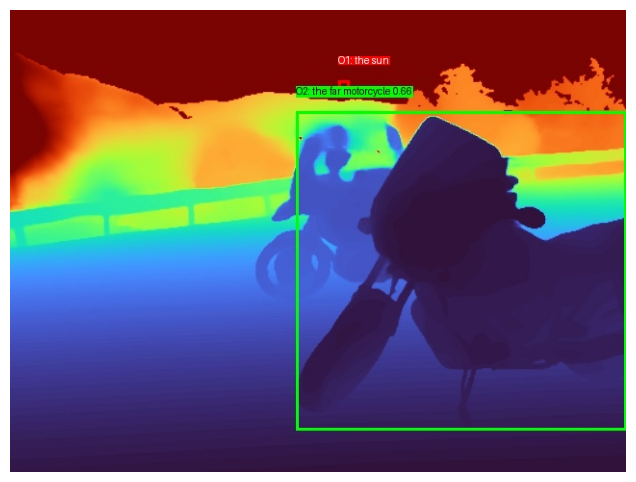

000000000178_depth.jpg


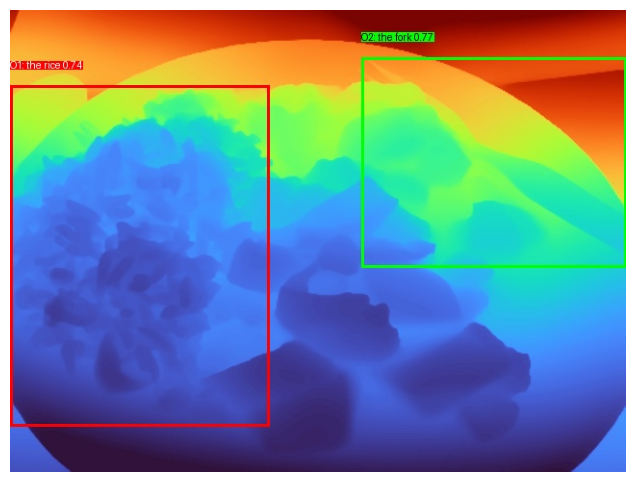

000000000205_depth.jpg


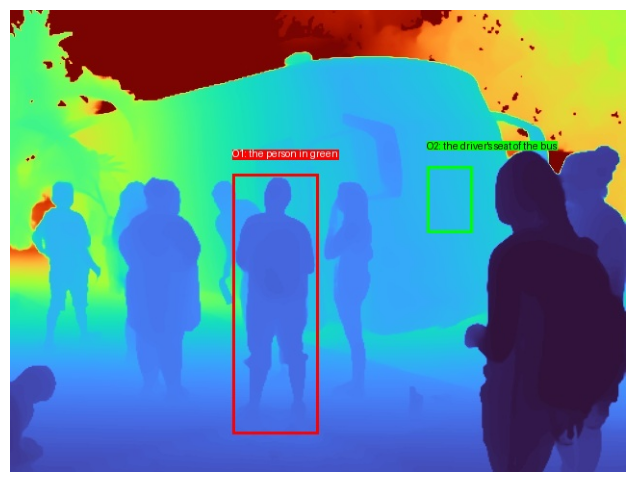

000000000453_depth.jpg


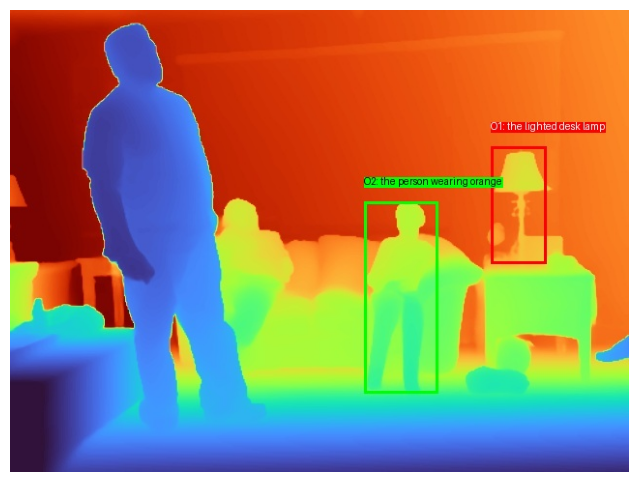

000000000456_depth.jpg


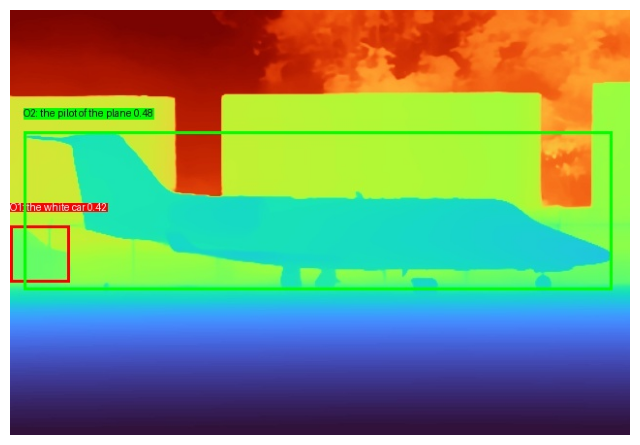

000000000463_depth.jpg


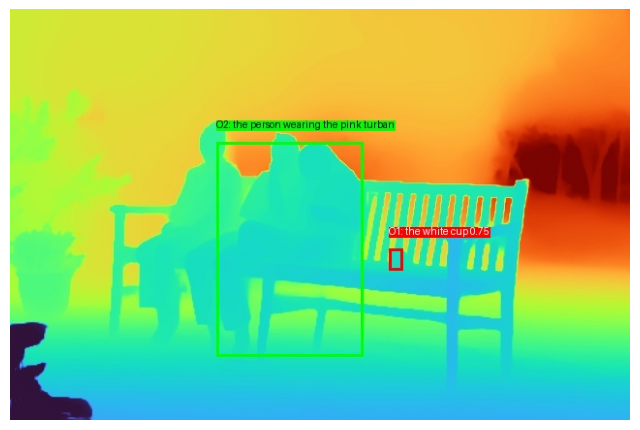

000000000686_depth.jpg


In [48]:
import matplotlib.pyplot as plt
import random

output_images = sorted(OUTPUT_DIR.glob("*_depth.jpg"))

print("Total output images:", len(output_images))

sample_images = output_images[:6]

for p in sample_images:
    img = Image.open(p).convert("RGB")

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print(p.name)

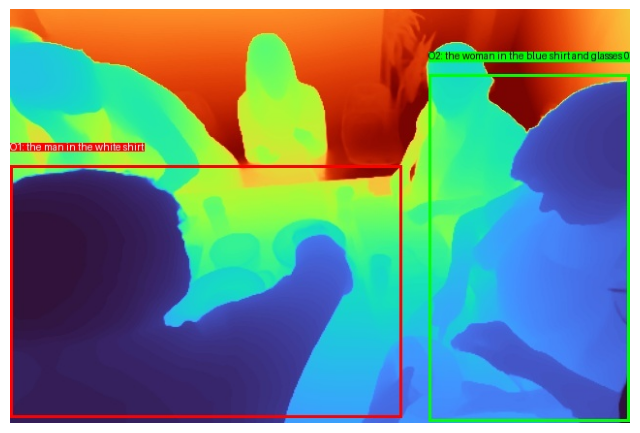

000000114987_depth.jpg


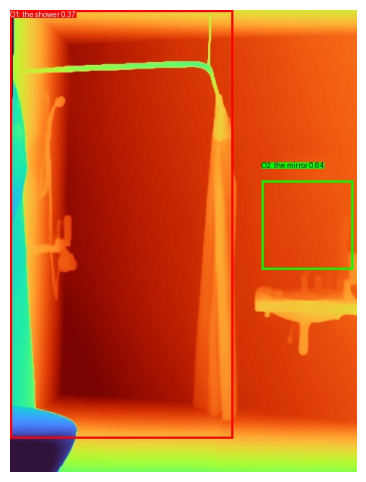

000000133538_depth.jpg


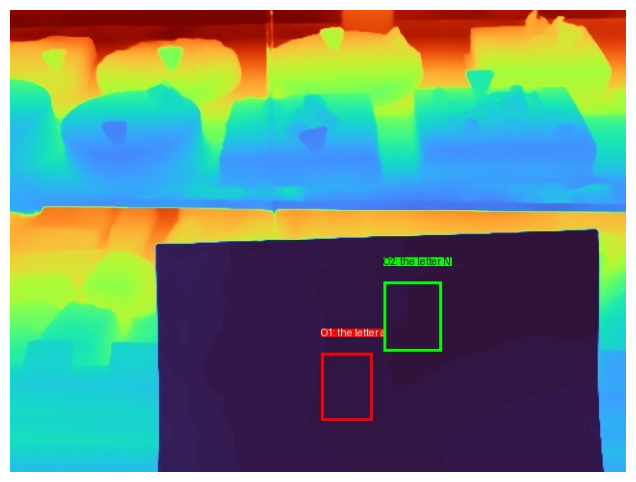

000000053179_depth.jpg


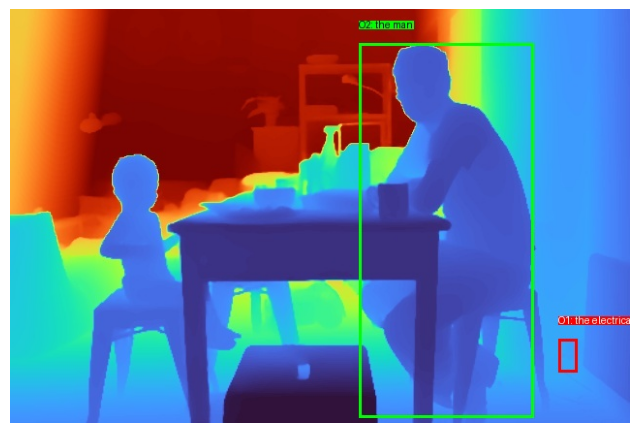

000000029022_depth.jpg


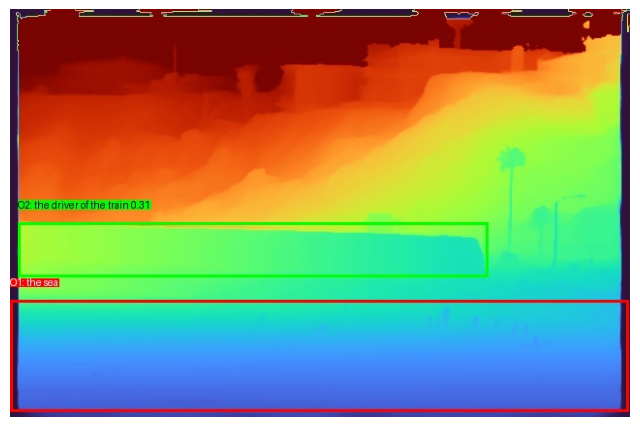

000000004769_depth.jpg


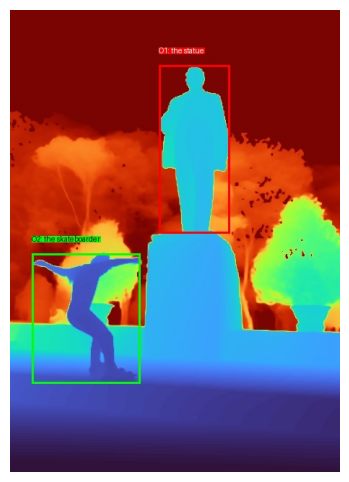

000000094688_depth.jpg


In [49]:
import random 

sample_images = random.sample(output_images, min(6, len(output_images)))

for p in sample_images:
    img = Image.open(p).convert("RGB")

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print(p.name)

In [50]:
!find /kaggle/working/depth_bbox_output -maxdepth 1 -type f | head -20
!echo "Total files:"
!find /kaggle/working/depth_bbox_output -maxdepth 1 -type f | wc -l

/kaggle/working/depth_bbox_output/000000104987_depth.jpg
/kaggle/working/depth_bbox_output/000000152862_depth.jpg
/kaggle/working/depth_bbox_output/000000082972_depth.jpg
/kaggle/working/depth_bbox_output/000000036786_depth.jpg
/kaggle/working/depth_bbox_output/000000199758_depth.jpg
/kaggle/working/depth_bbox_output/000000023408_depth.jpg
/kaggle/working/depth_bbox_output/000000048404_depth.jpg
/kaggle/working/depth_bbox_output/000000020798_depth.jpg
/kaggle/working/depth_bbox_output/000000066963_depth.jpg
/kaggle/working/depth_bbox_output/000000144966_depth.jpg
/kaggle/working/depth_bbox_output/000000065219_depth.jpg
/kaggle/working/depth_bbox_output/000000160686_depth.jpg
/kaggle/working/depth_bbox_output/000000062635_depth.jpg
/kaggle/working/depth_bbox_output/000000377930_depth.jpg
/kaggle/working/depth_bbox_output/000000204957_depth.jpg
/kaggle/working/depth_bbox_output/000000206967_depth.jpg
/kaggle/working/depth_bbox_output/000000075250_depth.jpg
/kaggle/working/depth_bbox_outp

In [51]:
ZIP_BASE = "/kaggle/working/depth_bbox_output"

zip_file = Path(ZIP_BASE + ".zip")
if zip_file.exists():
    zip_file.unlink()

shutil.make_archive(
    base_name=ZIP_BASE,
    format="zip",
    root_dir="/kaggle/working",
    base_dir="depth_bbox_output"
)

print("Created:", ZIP_BASE + ".zip")

Created: /kaggle/working/depth_bbox_output.zip


In [52]:
!ls -lh /kaggle/working/depth_bbox_output.zip

-rw-r--r-- 1 root root 52M Jul  5 04:42 /kaggle/working/depth_bbox_output.zip


In [53]:
from pathlib import Path
import json
import shutil
from PIL import Image, ImageDraw, ImageFont
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

JSON_PATH = Path("/kaggle/input/datasets/phmthn/depth-information/bboxes_last.json")
IMAGE_DIR = Path("/kaggle/input/datasets/lamnmh05/coco2017test/test_images/test_images")

OUTPUT_DIR = Path("/kaggle/working/bbox_original_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = Path("/kaggle/working/bbox_original_output.zip")

print("JSON_PATH:", JSON_PATH)
print("IMAGE_DIR:", IMAGE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Total JSON items:", len(data))
print(json.dumps(data[0], indent=2, ensure_ascii=False)[:2000])

JSON_PATH: /kaggle/input/datasets/phmthn/depth-information/bboxes_last.json
IMAGE_DIR: /kaggle/input/datasets/lamnmh05/coco2017test/test_images/test_images
OUTPUT_DIR: /kaggle/working/bbox_original_output
Total JSON items: 1076
{
  "id": 0,
  "image": "000000024001.jpg",
  "question": "If you were a person walking on the beach, on which side of you would the water be?",
  "O1": "the water",
  "O2": "a person walking on the beach",
  "image_width": 640,
  "image_height": 480,
  "detections": [
    {
      "label": "the water",
      "cls_id": 0,
      "confidence": null,
      "bbox_2d_1000": [
        0.0,
        408.0,
        1000.0,
        786.0
      ],
      "bbox_xyxy": [
        0.0,
        195.83999999999997,
        640.0,
        377.28000000000003
      ],
      "bbox_xywh": [
        0.0,
        195.83999999999997,
        640.0,
        181.44000000000005
      ],
      "bbox_source": "qwen"
    },
    {
      "label": "a person walking on the beach",
      "cls_id": 1

In [54]:
image_paths = []

for ext in ["*.jpg", "*.jpeg", "*.png", "*.webp", "*.bmp"]:
    image_paths.extend(IMAGE_DIR.rglob(ext))
    image_paths.extend(IMAGE_DIR.rglob(ext.upper()))

image_paths = sorted(list(set(image_paths)))

image_name_to_path = {p.name: p for p in image_paths}
image_stem_to_path = {p.stem: p for p in image_paths}

print("Found original images:", len(image_paths))

for p in image_paths[:10]:
    print(p)

Found original images: 1066
/kaggle/input/datasets/lamnmh05/coco2017test/test_images/test_images/000000000178.jpg
/kaggle/input/datasets/lamnmh05/coco2017test/test_images/test_images/000000000205.jpg
/kaggle/input/datasets/lamnmh05/coco2017test/test_images/test_images/000000000453.jpg
/kaggle/input/datasets/lamnmh05/coco2017test/test_images/test_images/000000000456.jpg
/kaggle/input/datasets/lamnmh05/coco2017test/test_images/test_images/000000000463.jpg
/kaggle/input/datasets/lamnmh05/coco2017test/test_images/test_images/000000000686.jpg
/kaggle/input/datasets/lamnmh05/coco2017test/test_images/test_images/000000000725.jpg
/kaggle/input/datasets/lamnmh05/coco2017test/test_images/test_images/000000000771.jpg
/kaggle/input/datasets/lamnmh05/coco2017test/test_images/test_images/000000000870.jpg
/kaggle/input/datasets/lamnmh05/coco2017test/test_images/test_images/000000001152.jpg


In [55]:
def get_font(font_size=22):
    try:
        return ImageFont.truetype("DejaVuSans.ttf", font_size)
    except:
        return ImageFont.load_default()


def safe_confidence(det):
    conf = det.get("confidence", None)

    if conf is None:
        return None

    try:
        return float(conf)
    except Exception:
        return None


def clamp(v, lo, hi):
    return max(lo, min(hi, float(v)))


def bbox_1000_to_pixel(bbox_1000, width, height):
    """
    Nếu bbox là hệ 0-1000 từ Qwen thì convert về pixel.
    """
    if bbox_1000 is None or len(bbox_1000) != 4:
        return None

    x1, y1, x2, y2 = bbox_1000

    x1 = clamp(x1, 0, 1000)
    y1 = clamp(y1, 0, 1000)
    x2 = clamp(x2, 0, 1000)
    y2 = clamp(y2, 0, 1000)

    px1 = x1 / 1000.0 * width
    py1 = y1 / 1000.0 * height
    px2 = x2 / 1000.0 * width
    py2 = y2 / 1000.0 * height

    px1, px2 = sorted([px1, px2])
    py1, py2 = sorted([py1, py2])

    return [px1, py1, px2, py2]


def fix_bbox_xyxy(bbox, width, height):
    """
    Clamp bbox pixel về trong ảnh.
    """
    if bbox is None or len(bbox) != 4:
        return None

    x1, y1, x2, y2 = map(float, bbox)

    x1 = clamp(x1, 0, width)
    x2 = clamp(x2, 0, width)
    y1 = clamp(y1, 0, height)
    y2 = clamp(y2, 0, height)

    x1, x2 = sorted([x1, x2])
    y1, y2 = sorted([y1, y2])

    return [x1, y1, x2, y2]


def get_bbox_for_drawing(det, width, height):
    """
    Ưu tiên bbox_xyxy.
    Nếu không có, dùng bbox_2d_1000 hoặc bbox_2d.
    """
    if "bbox_xyxy" in det and det["bbox_xyxy"] is not None:
        return fix_bbox_xyxy(det["bbox_xyxy"], width, height)

    if "bbox_2d_1000" in det and det["bbox_2d_1000"] is not None:
        return bbox_1000_to_pixel(det["bbox_2d_1000"], width, height)

    if "bbox_2d" in det and det["bbox_2d"] is not None:
        return bbox_1000_to_pixel(det["bbox_2d"], width, height)

    return None


def get_object_names(item):
    """
    Hỗ trợ cả format:
    item["O1"], item["O2"]
    hoặc item["Object"]["O1"], item["Object"]["O2"]
    """
    obj = item.get("Object", {})

    O1 = item.get("O1", obj.get("O1", "O1"))
    O2 = item.get("O2", obj.get("O2", "O2"))

    return O1, O2


def draw_bboxes_on_original_image(image_path, item, output_path):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    width, height = image.size

    line_width = max(3, int(min(width, height) / 160))
    font_size = max(16, int(min(width, height) / 28))
    font = get_font(font_size)

    O1, O2 = get_object_names(item)

    colors = {
        0: "red",
        1: "lime",
    }

    target_names = {
        0: "O1",
        1: "O2",
    }

    target_labels = {
        0: O1,
        1: O2,
    }

    detections = item.get("detections", [])
    drawn = []

    for det in detections:
        cls_id = det.get("cls_id", None)

        try:
            cls_id = int(cls_id)
        except:
            cls_id = None

        bbox = get_bbox_for_drawing(det, width, height)

        if bbox is None:
            continue

        x1, y1, x2, y2 = bbox

        color = colors.get(cls_id, "yellow")
        target_name = target_names.get(cls_id, "OBJ")
        label = target_labels.get(cls_id, det.get("label", "object"))

        draw.rectangle(
            [x1, y1, x2, y2],
            outline=color,
            width=line_width
        )

        conf = safe_confidence(det)

        if conf is None:
            text = f"{target_name}: {label}"
        else:
            text = f"{target_name}: {label} {conf:.2f}"

        text_x = int(x1)
        text_y = int(max(0, y1 - font_size - 8))

        try:
            text_bbox = draw.textbbox((text_x, text_y), text, font=font)
            draw.rectangle(text_bbox, fill=color)
        except:
            pass

        draw.text(
            (text_x, text_y),
            text,
            fill="black" if color in ["lime", "yellow"] else "white",
            font=font
        )

        drawn.append({
            "cls_id": cls_id,
            "label": label,
            "bbox_xyxy_drawn": [float(x1), float(y1), float(x2), float(y2)],
            "confidence": conf,
            "bbox_source": det.get("bbox_source", "unknown")
        })

    image.save(output_path, quality=95)

    return drawn

In [56]:
results = []
missing_images = []
items_without_detections = []

for item in tqdm(data, desc="Drawing bbox on original images"):
    image_name = item.get("image", "")
    image_stem = Path(image_name).stem

    image_path = image_name_to_path.get(image_name, None)

    if image_path is None:
        image_path = image_stem_to_path.get(image_stem, None)

    if image_path is None:
        missing_images.append({
            "id": item.get("id"),
            "image": image_name
        })
        continue

    detections = item.get("detections", [])

    if len(detections) == 0:
        items_without_detections.append({
            "id": item.get("id"),
            "image": image_name
        })

    output_path = OUTPUT_DIR / image_name

    drawn = draw_bboxes_on_original_image(
        image_path=image_path,
        item=item,
        output_path=output_path
    )

    O1, O2 = get_object_names(item)

    results.append({
        "id": item.get("id"),
        "image": image_name,
        "source_image_path": str(image_path),
        "output_path": str(output_path),
        "O1": O1,
        "O2": O2,
        "num_input_detections": len(detections),
        "num_drawn_detections": len(drawn),
        "drawn_detections": drawn
    })

print("Done.")
print("Total JSON items:", len(data))
print("Output images:", len(results))
print("Missing images:", len(missing_images))
print("Items without detections:", len(items_without_detections))
print("Output folder:", OUTPUT_DIR)

if missing_images:
    print("First missing images:")
    print(json.dumps(missing_images[:10], indent=2, ensure_ascii=False))

Drawing bbox on original images:   0%|          | 0/1076 [00:00<?, ?it/s]

Done.
Total JSON items: 1076
Output images: 1076
Missing images: 0
Items without detections: 16
Output folder: /kaggle/working/bbox_original_output


In [57]:
from pathlib import Path

FOLDER = Path("/kaggle/working/depth_bbox_output")

image_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

image_files = [
    p for p in FOLDER.iterdir()
    if p.is_file() and p.suffix.lower() in image_exts
]

print("Folder exists:", FOLDER.exists())
print("Total image files:", len(image_files))

for p in image_files[:10]:
    print(p.name)

Folder exists: True
Total image files: 1066
000000104987_depth.jpg
000000152862_depth.jpg
000000082972_depth.jpg
000000036786_depth.jpg
000000199758_depth.jpg
000000023408_depth.jpg
000000048404_depth.jpg
000000020798_depth.jpg
000000066963_depth.jpg
000000144966_depth.jpg


In [58]:
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

shutil.make_archive(
    base_name=str(ZIP_PATH).replace(".zip", ""),
    format="zip",
    root_dir="/kaggle/working",
    base_dir="bbox_original_output"
)

print("Created:", ZIP_PATH)

Created: /kaggle/working/bbox_original_output.zip


In [59]:
!ls -lh /kaggle/working/bbox_original_output.zip
!find /kaggle/working/bbox_original_output -maxdepth 1 -type f | wc -l

-rw-r--r-- 1 root root 139M Jul  5 04:43 /kaggle/working/bbox_original_output.zip
1066
